## Реализация своего дерева / случайного леса (модель)

In [139]:
"""Генерация данных"""
import numpy as np
import pandas as pd

def generate_real_estate_data(n_samples=2000, random_state=42):
    np.random.seed(random_state)
    
    # Основные признаки
    area = np.random.uniform(20, 150, n_samples)  # площадь
    rooms = np.random.randint(1, 6, n_samples)    # комнаты
    floor = np.random.randint(1, 25, n_samples)
    age = np.random.uniform(0, 50, n_samples)     # возраст дома
    
    # "Район" (категориальный, но пока числом)
    district = np.random.choice([0, 1, 2, 3], size=n_samples)
    
    # Базовая цена (нелинейная зависимость)
    price_per_m2 = (
        2000
        + 300 * rooms
        - 10 * age
        + 50 * np.sqrt(area)
        + 200 * (district == 0)
        + 100 * (district == 1)
        - 150 * (district == 3)
    )
    
    # Нелинейность через этаж
    price_per_m2 += 100 * np.sin(floor / 5)
    
    # Шум
    noise = np.random.normal(0, 200, n_samples)
    price_per_m2 += noise
    
    # Добавим выбросы (5%)
    n_outliers = int(0.05 * n_samples)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
    
    price_per_m2[outlier_idx] *= np.random.uniform(1.5, 3.0, n_outliers)
    
    # Иногда наоборот "слишком дешево"
    cheap_idx = np.random.choice(n_samples, n_outliers, replace=False)
    price_per_m2[cheap_idx] *= np.random.uniform(0.3, 0.7, n_outliers)
    
    # Собираем DataFrame
    df = pd.DataFrame({
        "area": area,
        "rooms": rooms,
        "floor": floor,
        "age": age,
        "district": district,
        "price_per_m2": price_per_m2
    })
    
    return df


# Пример использования
df = generate_real_estate_data()

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area          2000 non-null   float64
 1   rooms         2000 non-null   int32  
 2   floor         2000 non-null   int32  
 3   age           2000 non-null   float64
 4   district      2000 non-null   int32  
 5   price_per_m2  2000 non-null   float64
dtypes: float64(3), int32(3)
memory usage: 70.4 KB


In [141]:
df.head()

,area,rooms,floor,age,district,price_per_m2
0,68.690215,4,6,41.469258,3,3130.381715
1,143.592860,3,19,9.516849,2,3237.214436
2,115.159212,4,13,45.861030,0,7432.780135
3,97.825603,2,14,27.677927,0,2889.481085
4,40.282423,2,22,14.961600,0,2889.386907


In [143]:
df['price_per_m2'].describe()

count     2000.000000
mean      3270.177255
std       1124.003484
min        849.345210
25%       2718.745433
50%       3156.820630
75%       3596.812128
max      12134.014002
Name: price_per_m2, dtype: float64

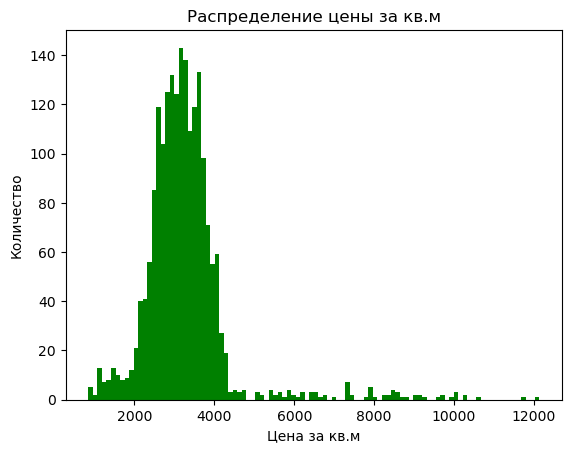

In [145]:
import matplotlib.pyplot as plt


plt.hist(df['price_per_m2'], color='green', bins=100)
plt.title('Распределение цены за кв.м')
plt.xlabel('Цена за кв.м')
plt.ylabel('Количество')
plt.show()

In [146]:
df['log цена'] = np.log(df['price_per_m2'])

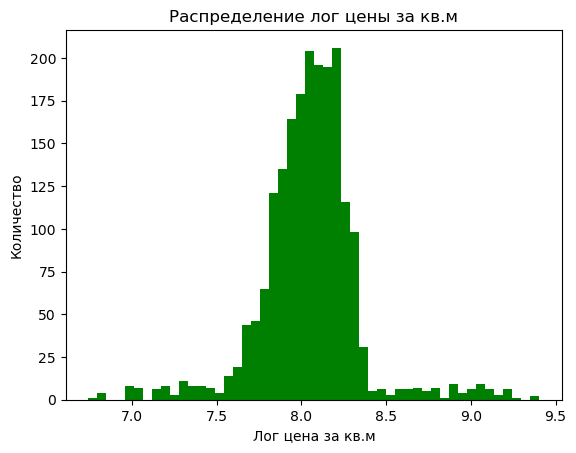

In [148]:
plt.hist(df['log цена'], color='green', bins=50)
plt.title('Распределение лог цены за кв.м')
plt.xlabel('Лог цена за кв.м')
plt.ylabel('Количество')
plt.show()

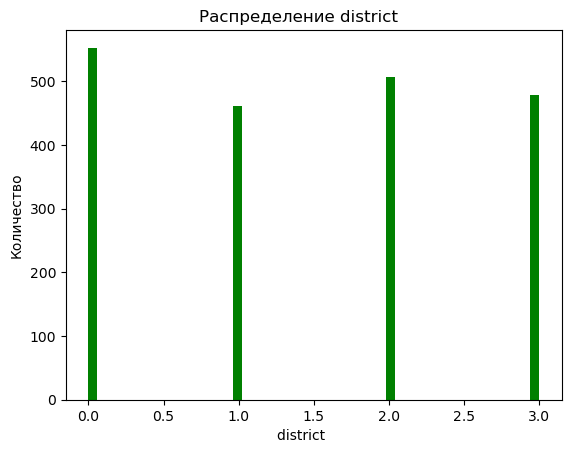

In [150]:
plt.hist(df['district'], color='green', bins=50)
plt.title('Распределение district      ')
plt.xlabel('district      ')
plt.ylabel('Количество')
plt.show()

In [151]:
df.head()

,area,rooms,floor,age,district,price_per_m2,log цена
0,68.690215,4,6,41.469258,3,3130.381715,8.048910
1,143.592860,3,19,9.516849,2,3237.214436,8.082468
2,115.159212,4,13,45.861030,0,7432.780135,8.913655
3,97.825603,2,14,27.677927,0,2889.481085,7.968832
4,40.282423,2,22,14.961600,0,2889.386907,7.968800


In [220]:
df = df.drop(columns=['district'])

In [221]:
df1 = df.drop(columns=['price_per_m2'])

In [222]:
df2 = df.drop(columns='log цена')

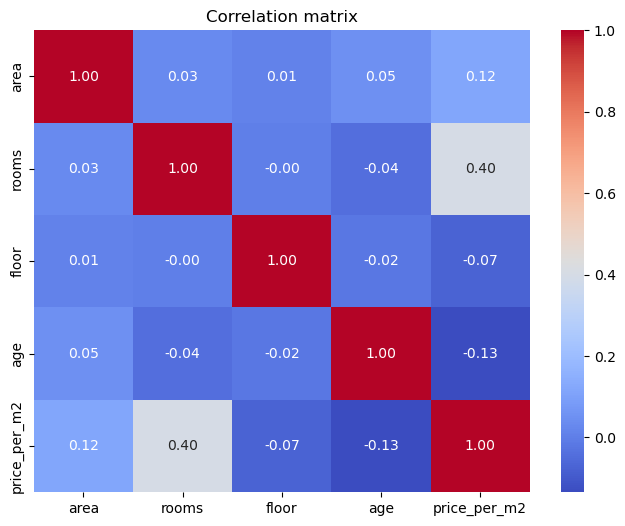

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['area', 'rooms', 'floor', 'age', 'price_per_m2']

corr = df2[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

In [233]:
df2.head()

,area,rooms,floor,age,price_per_m2
0,68.690215,4,6,41.469258,3130.381715
1,143.592860,3,19,9.516849,3237.214436
2,115.159212,4,13,45.861030,7432.780135
3,97.825603,2,14,27.677927,2889.481085
4,40.282423,2,22,14.961600,2889.386907


In [263]:
from sklearn.model_selection import train_test_split


#target = 'log цена'
X = df2.drop(columns=['price_per_m2'])
y = df2['price_per_m2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [264]:
X_train.values

array([[ 93.63260324,   2.        ,   4.        ,  44.93338508],
       [142.25961597,   2.        ,  22.        ,   0.4388606 ],
       [ 63.57564141,   2.        ,  15.        ,  11.18063099],
       ...,
       [120.81859017,   3.        ,  11.        ,   4.19812817],
       [105.65511113,   3.        ,  24.        ,  31.68770436],
       [ 31.30827879,   5.        ,  21.        ,  27.70938255]])

In [278]:
class Node():
    
    def __init__(self, feature=None, threshold=None, right=None, left=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.right = right
        self.left = left
        self.value = value
        

class DecisionTreeRegressor():
    
    def __init__(self, max_depth=5, min_samples_split=2, max_features=None, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.min_samples_leaf = min_samples_leaf
        self.root = None
    
    def print_tree(self, node=None, depth=0):
        if node is None:
            node = self.root
        
        if node.value is not None:
            print("  " * depth + f"Leaf: value={node.value:.2f}")
            return
        
        print("  " * depth + f"[X{node.feature} <= {node.threshold:.2f}]")
        self.print_tree(node.left, depth + 1)
        self.print_tree(node.right, depth + 1)
    
    
    def predict_with_path(self, x, node=None):
        if node is None:
            node = self.root
        
        if node.value is not None:
            print(f"Leaf reached → prediction = {node.value:.2f}")
            return node.value
        
        print(f"X[{node.feature}] = {x[node.feature]:.2f} <= {node.threshold:.2f}?")
        
        if x[node.feature] <= node.threshold:
            print("→ идём влево")
            return self.predict_with_path(x, node.left)
        else:
            print("→ идём вправо")
            return self.predict_with_path(x, node.right)
    
    
    def _find_best_split(self, X, y):
        
        # Задаем начальные значения
        best_loss = np.inf
        best_feature = None
        best_threshold = None
        n_samples, n_features = X.shape
        
        # Перебор индексов признаков
        features = np.random.choice(n_features, self.max_features, replace=False)
        for feature in features:
            values = X[:, feature]
            
            # Получаем индексы из отсортированного массива (быстрая реализация)
            sorted_idx = np.argsort(values)
            X_sorted = values[sorted_idx]
            y_sorted = y[sorted_idx]
            
            # Расчет параметров для формулы дисперсии
            total_sum = np.sum(y_sorted)
            total_sum_sq = np.sum(y_sorted ** 2)
            left_sum = 0.0
            left_sum_sq = 0.0
            left_count = 0
            right_sum = total_sum
            right_sum_sq = total_sum_sq
            right_count = n_samples
            
            # Перебор всех значений признаков (порог берем между i и i-1)
            for i in range(1, n_samples):
                xi_prev = X_sorted[i - 1]
                xi = X_sorted[i]
                yi = y_sorted[i - 1]
                
                # Пересчет для каждого значения
                left_count += 1
                right_count -= 1
                left_sum += yi
                left_sum_sq += yi ** 2
                right_sum -= yi
                right_sum_sq -= yi ** 2
                
                # Проверка, чтобы не брать одинаковые значения и не искать порог между ними
                if xi == xi_prev:
                    continue
                
                if left_count == 0 or right_count == 0:
                    continue
             
                # Расчет дисперсии для обеих частей 
                left_var = (left_sum_sq / left_count) - (left_sum / left_count) ** 2
                right_var = (right_sum_sq / right_count) - (right_sum / right_count) ** 2
                
                # Функция потерь для узла
                loss = (left_count / n_samples) * left_var + (right_count / n_samples) * right_var
                
                # Обновление значений
                if loss < best_loss:
                    best_loss = loss
                    best_feature = feature
                    best_threshold = (xi + xi_prev) / 2
                    
        return best_feature, best_threshold	
 
 
    def _build_tree(self, X, y, depth):
        # Условие остановки деления на узлы
        if depth >= self.max_depth or len(y) < self.min_samples_split or np.var(y) == 0:
            return Node(value=np.mean(y))
        
        # Находим лучшее разбиение
        feature, threshold = self._find_best_split(X, y)
        
        # Если нет лучшего разбиения
        if feature is None: 
            return Node(value=np.mean(y))
        
        # Разбиение
        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold
        
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            return Node(value=np.mean(y))
        
        if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
            return Node(value=np.mean(y))
        
        X_left, y_left = X[left_mask], y[left_mask]
        X_right, y_right = X[right_mask], y[right_mask]
        
        # Рекурсия
        left_node = self._build_tree(X_left, y_left, depth+1)
        right_node = self._build_tree(X_right, y_right, depth+1)
        
        return Node(feature=feature,
                    threshold=threshold, 
                    right=right_node,
                    left=left_node)
        
        
    def fit(self, X, y):
        self.root = self._build_tree(X=X, y=y, depth=0)
        
    
    def _predict_one(self, x, node):
        
        # Проверка, является ли листом
        if node.value is not None:
            return node.value     
        
        # Идем налево или направо
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)
        
        
    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])
    

class RandomForest():
    
    def __init__(self, n_estimators=50, max_depth=8, min_samples_split=2, min_samples_leaf=1 , max_features=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.trees = []
    

    def plot_tree_predictions(self, X, sample_idx=0):
        preds = np.array([tree.predict(X)[sample_idx] for tree in self.trees])
        
        plt.hist(preds, bins=20)
        plt.axvline(np.mean(preds), linestyle='dashed')
        plt.title(f"Predictions distribution (sample {sample_idx})")
        plt.show()
    
    
    def predict_all_trees(self, X):
        return np.array([tree.predict(X) for tree in self.trees])


    def _bootstrap(self, x, y):
        idx = np.random.choice(np.arange(len(x)), size=len(x), replace=True)
        return x[idx], y[idx]
        
        
    def fit(self, X, y):
        self.trees = []
        for i in range(self.n_estimators):
            new_x, new_y = self._bootstrap(X, y)
            tree = DecisionTreeRegressor(max_depth=self.max_depth, min_samples_split=self.min_samples_split, 
                                         min_samples_leaf=self.min_samples_leaf, max_features=self.max_features)
            tree.fit(new_x, new_y)
            self.trees.append(tree)
            
    
    def predict(self, X):
        return np.mean(np.array([tree.predict(X) for tree in self.trees]), axis=0)
                    

In [346]:
forest = RandomForest(n_estimators=1000, max_depth=8, min_samples_split=4, min_samples_leaf=3, max_features=2)
forest.fit(X_train.values, y_train.values)

In [347]:
tree = forest.trees[0]
tree.print_tree()

[X3 <= 24.39]
  [X0 <= 68.53]
    [X1 <= 3.50]
      [X0 <= 38.16]
        Leaf: value=3036.20
        Leaf: value=2768.18
      [X2 <= 4.00]
        [X1 <= 4.50]
          [X2 <= 2.00]
            Leaf: value=3639.57
            Leaf: value=3285.26
          [X2 <= 2.00]
            Leaf: value=3742.46
            Leaf: value=4826.66
        [X2 <= 5.50]
          Leaf: value=2780.79
          [X2 <= 20.50]
            [X3 <= 8.33]
              [X2 <= 19.50]
                Leaf: value=3726.88
                Leaf: value=5080.27
              [X2 <= 17.50]
                Leaf: value=3583.57
                Leaf: value=3323.15
            [X3 <= 20.48]
              [X3 <= 7.33]
                Leaf: value=3271.34
                Leaf: value=3497.78
              Leaf: value=2955.91
    [X1 <= 4.50]
      [X1 <= 2.50]
        [X0 <= 87.37]
          [X0 <= 86.40]
            [X3 <= 16.55]
              [X2 <= 11.50]
                Leaf: value=2987.94
                Leaf: value=5246

In [348]:
x = X_test.values[0]
tree.predict_with_path(x)

X[3] = 34.42 <= 24.39?
→ идём вправо
X[3] = 34.42 <= 39.29?
→ идём влево
X[1] = 1.00 <= 3.50?
→ идём влево
X[0] = 120.94 <= 142.51?
→ идём влево
X[1] = 1.00 <= 1.50?
→ идём влево
X[2] = 18.00 <= 14.50?
→ идём вправо
X[3] = 34.42 <= 33.59?
→ идём вправо
Leaf reached → prediction = 2288.48


2288.4769809145014

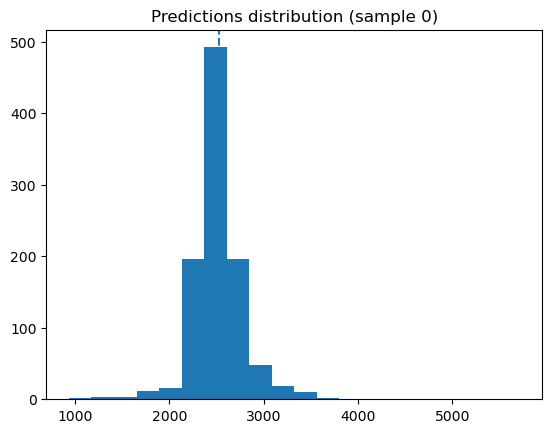

In [349]:
forest.plot_tree_predictions(X_test.values, sample_idx=0)

In [350]:
y_pred = forest.predict(X_test.values)
"""Метрики для теста"""
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 467.78279418770745
MSE: 923841.1815716806
RMSE: 961.1665732700449
R2: 0.14813287013999432


In [351]:
y_pred_train = forest.predict(X_train.values)
"""Метрики для трейна"""
mae_train = np.mean(np.abs(y_train - y_pred_train))
mse_train = np.mean((y_train - y_pred_train) ** 2)
rmse_train = np.sqrt(mse_train)
ss_res_train = np.sum((y_train - y_pred_train) ** 2)
ss_tot_train = np.sum((y_train - np.mean(y_train)) ** 2)
r2_train = 1 - ss_res_train / ss_tot_train
print(f"MAE: {mae_train}")
print(f"MSE: {mse_train}")
print(f"RMSE: {rmse_train}")
print(f"R2: {r2_train}")

MAE: 405.9885613041044
MSE: 787694.8860720131
RMSE: 887.5217665342146
R2: 0.3974325624861794


In [262]:
df2['price_per_m2'].mean()

3270.1772552206266

In [236]:
tree = DecisionTreeRegressor(max_depth=5, min_samples_split=2)
tree.fit(X_train.values, y_train.values)

In [ ]:
y_pred = tree.predict(X_test.values)

In [238]:
y_pred_price = y_pred
y_test_price = y_test.values

In [ ]:
"""Метрики дерева"""
mae = np.mean(np.abs(y_test_price - y_pred_price))
mse = np.mean((y_test_price - y_pred_price) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_test_price - y_pred_price) ** 2)
ss_tot = np.sum((y_test_price - np.mean(y_test_price)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 528.952682179333
MSE: 1180091.6290283564
RMSE: 1086.3202239801838
R2: 0.07075454824112326


In [ ]:
"""Вывод:  Лес написан нормально, надо преобразовывать признаки, чтобы они дали больший сигнал. Так как задачей являлось реализовать случайный лес без использования sklearn, то на этом задачу можно завершить."""